In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


I0000 00:00:1784957241.699935    7504 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784957242.013863    7504 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784957244.828580    7504 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

# Base paths (relative to notebook location in notebooks/)
BASE_DIR = os.path.abspath("..")  # D:\HealthAI-Project
DATA_DIR = os.path.join(BASE_DIR, "datasets", "chest_xray", "chest_xray")  # D:\HealthAI-Project\datasets\chest_xray\chest_xray

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)


BASE_DIR: /home/chandan/Internship/HealthAI-Project
DATA_DIR: /home/chandan/Internship/HealthAI-Project/datasets/chest_xray/chest_xray
TRAIN_DIR: /home/chandan/Internship/HealthAI-Project/datasets/chest_xray/chest_xray/train
VAL_DIR: /home/chandan/Internship/HealthAI-Project/datasets/chest_xray/chest_xray/test


Set Up ImageDataGenerator

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model Skeleton (Transfer Learning)

In [4]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # we will fine-tune later

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # binary: NORMAL vs PNEUMONIA
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train the Pneumonia Model (Light Training Pass)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

EPOCHS = 20  # start with 20

checkpoint_path = os.path.join(BASE_DIR, "models", "xray_disease_model.keras")
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20


I0000 00:00:1784957249.386652    7504 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


163/163 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8583 - loss: 0.3050 - val_accuracy: 0.7853 - val_loss: 0.3970
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9243 - loss: 0.1827 - val_accuracy: 0.8830 - val_loss: 0.2695
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9442 - loss: 0.1460 - val_accuracy: 0.8862 - val_loss: 0.2623
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9444 - loss: 0.1384 - val_accuracy: 0.8766 - val_loss: 0.2805
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9461 - loss: 0.1303 - val_accuracy: 0.8638 - val_loss: 0.3156


In [6]:
val_loss, val_acc = model.evaluate(val_gen)
print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 699ms/step - accuracy: 0.8862 - loss: 0.2623
Validation loss: 0.2623465955257416
Validation accuracy: 0.8862179517745972


Get class mapping (NORMAL vs PNEUMONIA)

In [7]:
# Check class indices used by the generator
class_indices = train_gen.class_indices
print(class_indices)

# Reverse mapping: 0 -> NORMAL, 1 -> PNEUMONIA (or as per your dataset)
idx_to_class = {v: k for k, v in class_indices.items()}
print(idx_to_class)


{'NORMAL': 0, 'PNEUMONIA': 1}
{0: 'NORMAL', 1: 'PNEUMONIA'}


In [8]:
import json
import os
from pathlib import Path

BASE_DIR = Path("..").resolve()  # D:\HealthAI-Project
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

mapping_path = MODELS_DIR / "xray_class_mapping.json"

# idx_to_class should look like {0: 'NORMAL', 1: 'PNEUMONIA'}
print("idx_to_class:", idx_to_class)

# Save as JSON (keys as strings)
with open(mapping_path, "w") as f:
    json.dump({str(k): v for k, v in idx_to_class.items()}, f, indent=2)

print("Saved class mapping to:", mapping_path)


idx_to_class: {0: 'NORMAL', 1: 'PNEUMONIA'}
Saved class mapping to: /home/chandan/Internship/HealthAI-Project/models/xray_class_mapping.json


Helper: predict on a single X-ray image

In [9]:
import tensorflow as tf
import numpy as np
import os

def predict_xray_image(img_path, model, idx_to_class, img_size=(224, 224)):
    # Load image
    img = tf.keras.utils.load_img(img_path, target_size=img_size, color_mode='rgb')
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0  # same normalization as training
    img_array = np.expand_dims(img_array, axis=0)  # (1, H, W, 3)

    # Predict
    prob = model.predict(img_array)[0][0]  # single scalar between 0 and 1

    # Threshold at 0.5
    predicted_class_index = 1 if prob >= 0.5 else 0
    predicted_label = idx_to_class[predicted_class_index]

    # For convenience, give pneumonia probability as "prob of class 1"
    pneumonia_prob = float(prob)
    
    return {
        "predicted_label": predicted_label,
        "pneumonia_probability": pneumonia_prob
    }


Test with a real image from your dataset

PNEUMONIA SET

In [10]:
test_example_path = os.path.join(
    VAL_DIR,  # this is pointing to .../chest_xray/test
    "PNEUMONIA",
    os.listdir(os.path.join(VAL_DIR, "PNEUMONIA"))[0]  # first pneumonia image
)

print("Sample test image:", test_example_path)

result = predict_xray_image(test_example_path, model, idx_to_class, IMG_SIZE)
print(result)


Sample test image: /home/chandan/Internship/HealthAI-Project/datasets/chest_xray/chest_xray/test/PNEUMONIA/person152_bacteria_722.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
{'predicted_label': 'PNEUMONIA', 'pneumonia_probability': 0.9992221593856812}


NORMAL SET

In [11]:
test_normal_path = os.path.join(
    VAL_DIR,
    "NORMAL",
    os.listdir(os.path.join(VAL_DIR, "NORMAL"))[0]
)

print("Sample NORMAL image:", test_normal_path)

result_normal = predict_xray_image(test_normal_path, model, idx_to_class, IMG_SIZE)
print(result_normal)


Sample NORMAL image: /home/chandan/Internship/HealthAI-Project/datasets/chest_xray/chest_xray/test/NORMAL/NORMAL2-IM-0376-0001.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
{'predicted_label': 'PNEUMONIA', 'pneumonia_probability': 0.5475071668624878}


SAVE THE MODEL

In [12]:
checkpoint_path = os.path.join(BASE_DIR, "models", "xray_disease_model.h5")


In [13]:
print("Epochs actually trained:", len(history.history["loss"]))

Epochs actually trained: 5


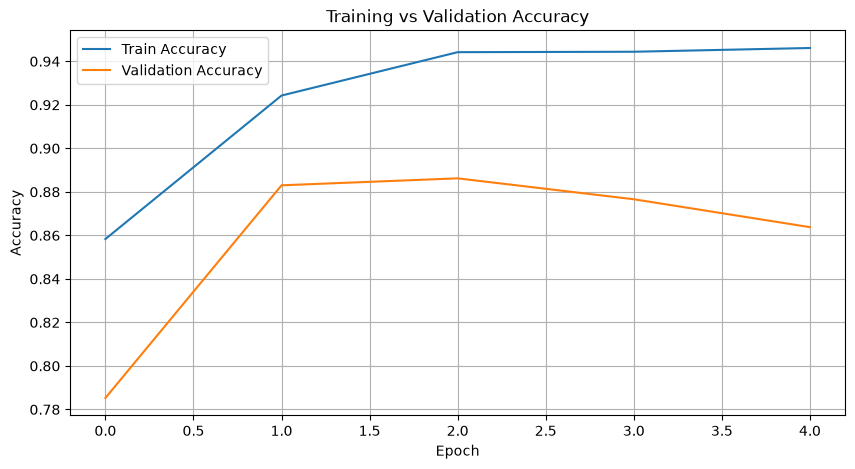

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

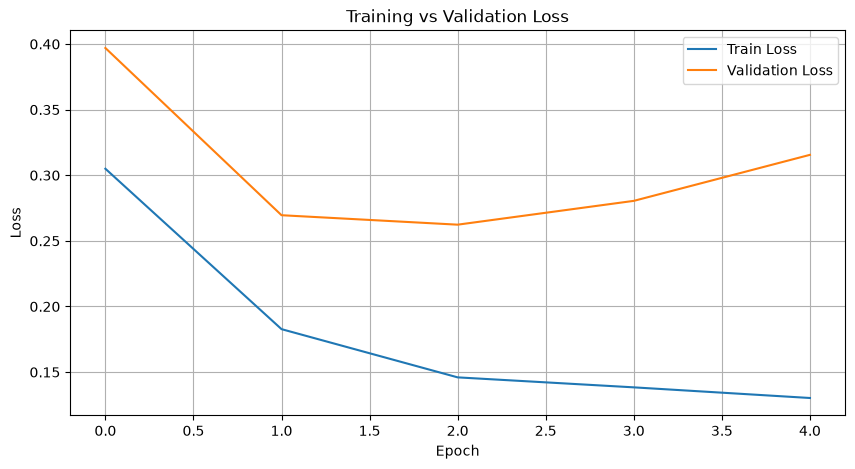

In [15]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(val_gen)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 807ms/step - accuracy: 0.8862 - loss: 0.2623
Test Loss: 0.2623465657234192
Test Accuracy: 0.8862179517745972


In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
pred = model.predict(val_gen)
pred = (pred > 0.5).astype(int)

print(confusion_matrix(val_gen.classes, pred))
print(classification_report(val_gen.classes, pred, target_names=val_gen.class_indices.keys()))

20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step
[[ 68 166]
 [117 273]]
              precision    recall  f1-score   support

      NORMAL       0.37      0.29      0.32       234
   PNEUMONIA       0.62      0.70      0.66       390

    accuracy                           0.55       624
   macro avg       0.49      0.50      0.49       624
weighted avg       0.53      0.55      0.53       624

